EXPERIMENT 16
Reinforcement Learning Application Development
and Performance Evaluation using TensorFlow/Keras
Episode: 20 | Reward: 15.0 | Loss: 0.168
Episode: 40 | Reward: 17.0 | Loss: 0.2662
Episode: 60 | Reward: 9.0 | Loss: 0.7124
Episode: 80 | Reward: 12.0 | Loss: 0.3724
Episode: 100 | Reward: 35.0 | Loss: 0.4016


SAMPLE APPLICATION DATA


,Episode,Reward,Loss,Epsilon,Steps,Action_0_Count,Action_1_Count
0,1,24.0,0.000000,0.970000,24,10,14
1,2,13.0,0.518945,0.940900,13,2,11
2,3,19.0,0.439828,0.912673,19,12,7
3,4,16.0,0.353773,0.885293,16,12,4
4,5,23.0,0.297000,0.858734,23,9,14
5,6,13.0,0.236737,0.832972,13,3,10
6,7,33.0,0.179073,0.807983,33,14,19
7,8,28.0,0.118446,0.783743,28,12,16
8,9,10.0,0.113307,0.760231,10,2,8
9,10,13.0,0.086412,0.737424,13,5,8


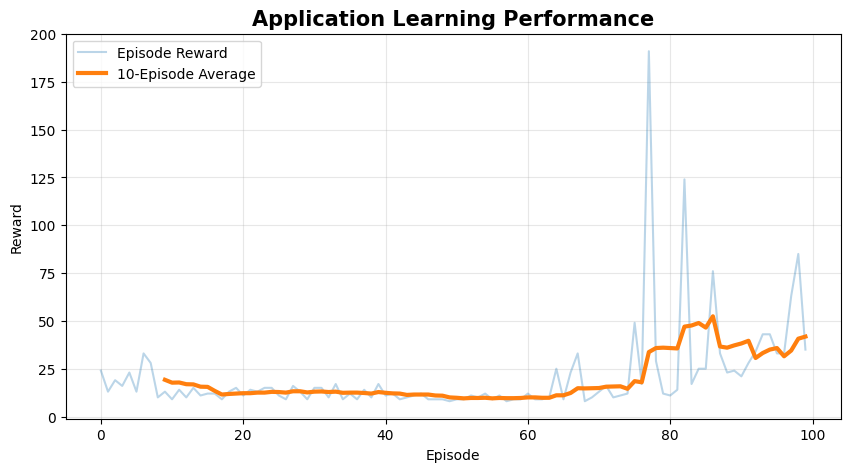

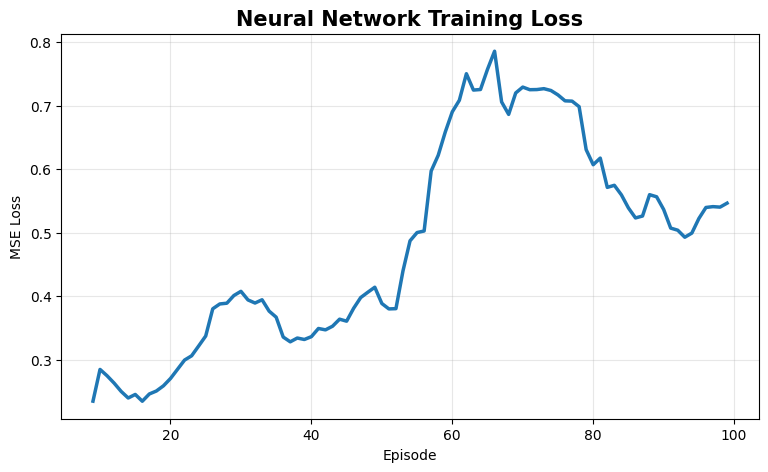

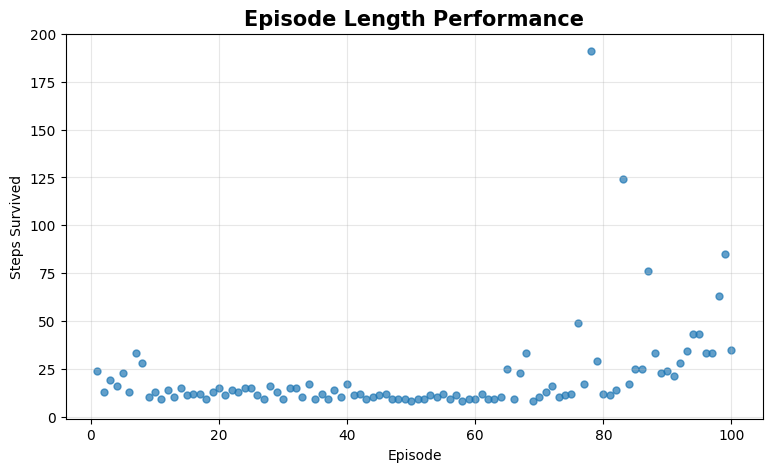

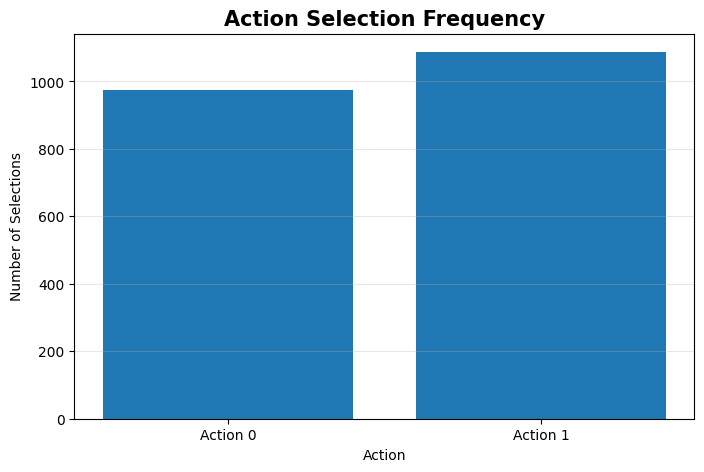

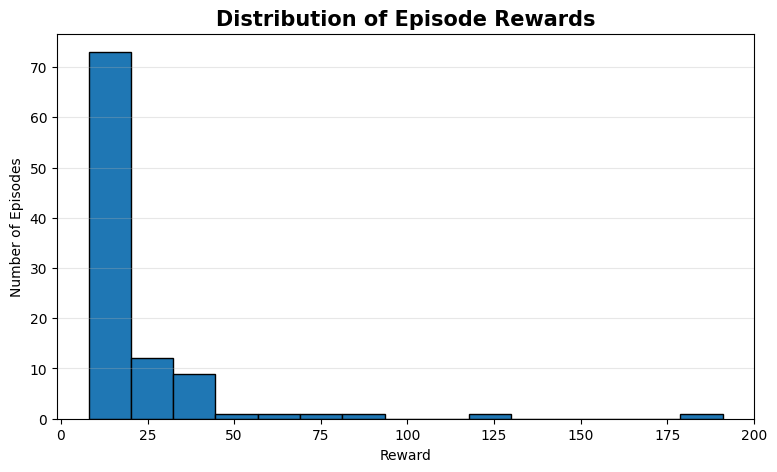

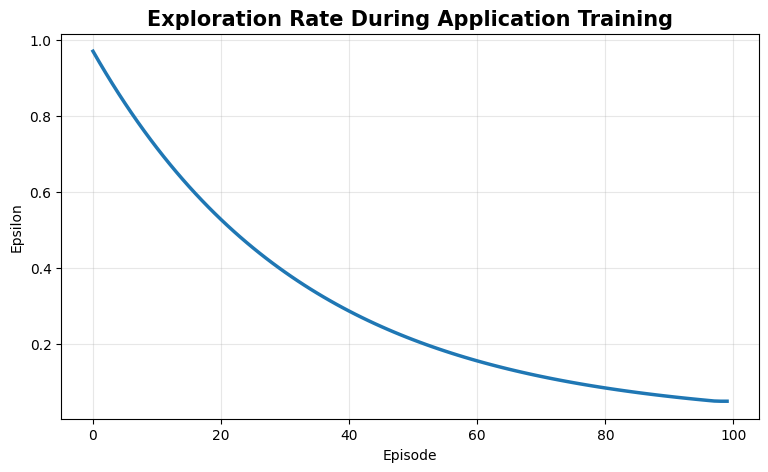



APPLICATION PERFORMANCE SUMMARY


,Performance Measure,Result
0,Algorithm,DQN using TensorFlow/Keras
1,Environment,CartPole-v1
2,Training Episodes,100
3,Initial Average Reward,15.6
4,Final Average Reward,39.5
5,Maximum Reward,191.0
6,Final Reward Variance,772.26
7,Average Steps,39.5
8,Performance Improvement,153.21%
9,Training Time,306.83


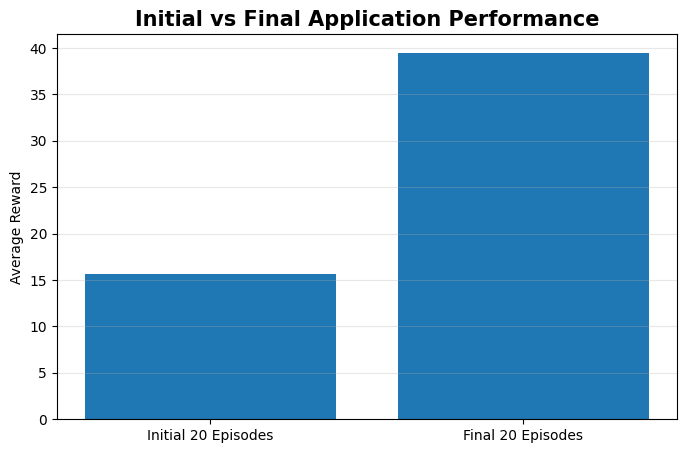



FINAL RESULT
Initial Average Reward: 15.6
Final Average Reward: 39.5
Maximum Reward: 191.0
Final Reward Variance: 772.26
Average Steps: 39.5
Performance Improvement: 153.21 %
Training Time: 306.83 seconds


CONCLUSION
A reinforcement learning application was successfully
developed using TensorFlow and Keras.
The DQN agent learned to interact with the CartPole
environment through experience replay and a target network.
Application performance was evaluated using reward,
training loss, episode length, action selection,
reward distribution and exploration rate.
The initial and final performance were compared to
measure the improvement achieved through learning.

Generated Files:
1. RL_Application_Full_Dataset.csv
2. RL_Application_Summary.csv

Experiment 16 Completed Successfully.


In [1]:
!pip -q install gymnasium tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gymnasium as gym
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
import time

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("="*75)
print("EXPERIMENT 16")
print("Reinforcement Learning Application Development")
print("and Performance Evaluation using TensorFlow/Keras")
print("="*75)

EPISODES=100
GAMMA=0.95
LR=0.001
BATCH=32
MEMORY_SIZE=3000
EPSILON=1.0
EPS_MIN=0.05
EPS_DECAY=0.97

env=gym.make("CartPole-v1")

state_size=4
action_size=2

model=Sequential([
    Input(shape=(state_size,)),
    Dense(64,activation="relu"),
    Dense(64,activation="relu"),
    Dense(action_size,activation="linear")
])

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="mse"
)

target_model=Sequential([
    Input(shape=(state_size,)),
    Dense(64,activation="relu"),
    Dense(64,activation="relu"),
    Dense(action_size,activation="linear")
])

target_model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="mse"
)

target_model.set_weights(
    model.get_weights()
)

memory=deque(
    maxlen=MEMORY_SIZE
)

rewards=[]
losses=[]
epsilons=[]
steps_history=[]
action0=[]
action1=[]

start=time.time()

for episode in range(EPISODES):

    state,_=env.reset()

    total_reward=0
    total_loss=0
    loss_count=0
    steps=0
    count0=0
    count1=0
    done=False

    while not done:

        if np.random.random()<EPSILON:
            action=np.random.randint(action_size)
        else:
            q_values=model.predict(
                np.array([state],dtype=np.float32),
                verbose=0
            )
            action=int(np.argmax(q_values[0]))

        if action==0:
            count0+=1
        else:
            count1+=1

        next_state,reward,terminated,truncated,_=env.step(action)

        done=terminated or truncated

        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

        if len(memory)>=BATCH and steps%4==0:

            batch=random.sample(
                list(memory),
                BATCH
            )

            states=np.array(
                [x[0] for x in batch],
                dtype=np.float32
            )

            actions=np.array(
                [x[1] for x in batch],
                dtype=np.int32
            )

            rewards_batch=np.array(
                [x[2] for x in batch],
                dtype=np.float32
            )

            next_states=np.array(
                [x[3] for x in batch],
                dtype=np.float32
            )

            dones=np.array(
                [x[4] for x in batch],
                dtype=bool
            )

            current_q=model.predict(
                states,
                verbose=0
            )

            next_q=target_model.predict(
                next_states,
                verbose=0
            )

            targets=current_q.copy()

            for i in range(BATCH):

                if dones[i]:
                    targets[i,actions[i]]=rewards_batch[i]
                else:
                    targets[i,actions[i]]=(
                        rewards_batch[i]
                        +GAMMA*np.max(next_q[i])
                    )

            history=model.fit(
                states,
                targets,
                epochs=1,
                verbose=0
            )

            total_loss+=float(
                history.history["loss"][0]
            )

            loss_count+=1

        state=next_state
        total_reward+=reward
        steps+=1

    EPSILON=max(
        EPS_MIN,
        EPSILON*EPS_DECAY
    )

    if (episode+1)%10==0:
        target_model.set_weights(
            model.get_weights()
        )

    rewards.append(total_reward)

    losses.append(
        total_loss/loss_count
        if loss_count>0 else 0
    )

    epsilons.append(EPSILON)
    steps_history.append(steps)

    action0.append(count0)
    action1.append(count1)

    if (episode+1)%20==0:
        print(
            "Episode:",
            episode+1,
            "| Reward:",
            round(total_reward,2),
            "| Loss:",
            round(losses[-1],4)
        )

training_time=time.time()-start

env.close()

dataset=pd.DataFrame({
    "Episode":range(1,EPISODES+1),
    "Reward":rewards,
    "Loss":losses,
    "Epsilon":epsilons,
    "Steps":steps_history,
    "Action_0_Count":action0,
    "Action_1_Count":action1
})

print("\n")
print("="*75)
print("SAMPLE APPLICATION DATA")
print("="*75)

display(dataset.head(10))

dataset.to_csv(
    "RL_Application_Full_Dataset.csv",
    index=False
)

plt.figure(figsize=(10,5))

plt.plot(
    dataset["Reward"],
    alpha=0.3,
    label="Episode Reward"
)

plt.plot(
    dataset["Reward"].rolling(10).mean(),
    linewidth=3,
    label="10-Episode Average"
)

plt.title(
    "Application Learning Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Loss"].rolling(10).mean(),
    linewidth=2.5
)

plt.title(
    "Neural Network Training Loss",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.scatter(
    dataset["Episode"],
    dataset["Steps"],
    s=25,
    alpha=0.7
)

plt.title(
    "Episode Length Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Steps Survived")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    ["Action 0","Action 1"],
    [
        dataset["Action_0_Count"].sum(),
        dataset["Action_1_Count"].sum()
    ]
)

plt.title(
    "Action Selection Frequency",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Action")
plt.ylabel("Number of Selections")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

plt.figure(figsize=(9,5))

plt.hist(
    dataset["Reward"],
    bins=15,
    edgecolor="black"
)

plt.title(
    "Distribution of Episode Rewards",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Reward")
plt.ylabel("Number of Episodes")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Epsilon"],
    linewidth=2.5
)

plt.title(
    "Exploration Rate During Application Training",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.grid(alpha=0.3)

plt.show()

first_reward=dataset["Reward"].head(20).mean()
last_reward=dataset["Reward"].tail(20).mean()
maximum_reward=dataset["Reward"].max()
reward_variance=dataset["Reward"].tail(20).var()
average_steps=dataset["Steps"].tail(20).mean()

improvement=(
    ((last_reward-first_reward)/
     max(abs(first_reward),1))*100
)

summary=pd.DataFrame({
    "Performance Measure":[
        "Algorithm",
        "Environment",
        "Training Episodes",
        "Initial Average Reward",
        "Final Average Reward",
        "Maximum Reward",
        "Final Reward Variance",
        "Average Steps",
        "Performance Improvement",
        "Training Time"
    ],
    "Result":[
        "DQN using TensorFlow/Keras",
        "CartPole-v1",
        EPISODES,
        round(first_reward,2),
        round(last_reward,2),
        round(maximum_reward,2),
        round(reward_variance,2),
        round(average_steps,2),
        str(round(improvement,2))+"%",
        round(training_time,2)
    ]
})

print("\n")
print("="*75)
print("APPLICATION PERFORMANCE SUMMARY")
print("="*75)

display(summary)

summary.to_csv(
    "RL_Application_Summary.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    [
        "Initial 20 Episodes",
        "Final 20 Episodes"
    ],
    [
        first_reward,
        last_reward
    ]
)

plt.title(
    "Initial vs Final Application Performance",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Average Reward")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

print("\n")
print("="*75)
print("FINAL RESULT")
print("="*75)

print(
    "Initial Average Reward:",
    round(first_reward,2)
)

print(
    "Final Average Reward:",
    round(last_reward,2)
)

print(
    "Maximum Reward:",
    round(maximum_reward,2)
)

print(
    "Final Reward Variance:",
    round(reward_variance,2)
)

print(
    "Average Steps:",
    round(average_steps,2)
)

print(
    "Performance Improvement:",
    round(improvement,2),"%"
)

print(
    "Training Time:",
    round(training_time,2),
    "seconds"
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "A reinforcement learning application was successfully"
)

print(
    "developed using TensorFlow and Keras."
)

print(
    "The DQN agent learned to interact with the CartPole"
)

print(
    "environment through experience replay and a target network."
)

print(
    "Application performance was evaluated using reward,"
)

print(
    "training loss, episode length, action selection,"
)

print(
    "reward distribution and exploration rate."
)

print(
    "The initial and final performance were compared to"
)

print(
    "measure the improvement achieved through learning."
)

print("\nGenerated Files:")
print("1. RL_Application_Full_Dataset.csv")
print("2. RL_Application_Summary.csv")

print("\nExperiment 16 Completed Successfully.")